# RuneScape Bond / S&P 500 Investigation
## Section 0 — Setup and Imports

**Question:** do OSRS bond returns carry genuine information about *future* S&P 500 returns, and is it incremental to familiar risk and sentiment indicators? Correlation alone is not predictive evidence, and prediction alone is not a causal mechanism.

This lab journal first establishes data identity and coverage, reserves a chronological holdout, tests stationarity, searches training-only lead/lag structure, and challenges it with controls and Granger tests. A locked walk-forward rule gets one final evaluation. Full-history regime interpretation is deliberately deferred until that evaluation is saved.

**Corrections to the original proposal:** OSRS item `12532` is a Dragon sq shield ornament kit; the tradeable [Old school bond is `13190`](https://oldschool.runescape.wiki/w/Old_school_bond), introduced in March 2015, not 2013. The existing v1 timeseries fetcher returns a rolling daily snapshot (365 rows when checked), not a backfillable archive. The [current wiki API documentation](https://oldschool.runescape.wiki/w/RuneScape:Real-time_Prices) also describes bounded lookbacks. We reuse the repository fetchers and take **every returned day**, but never invent earlier observations or claim unobserved regime coverage.

Run from the repository root after `pip install -r requirements.txt`. Run Sections 0–1 once per kernel; **any later section can then run independently**, recomputing its training prerequisites from cache. Section 8 never opens an unevaluated holdout. On a fresh run, Section 6 shows training history; Section 7 then renders its full-history counterpart after saving the holdout. Once test results have been seen, reruns are reproduction, not new evidence.


In [1]:
from pathlib import Path
from hashlib import sha256
from functools import lru_cache
import numpy as np
import pandas as pd
import scipy.stats as stats
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from arch.unitroot import ADF, KPSS
from pandas_datareader import data as pdr
import ruptures as rpt
from IPython.display import Markdown, display

# Reuse the original network implementation directly, not a notebook rewrite.
from bond_sp500_correlation import fetch_rs_timeseries, fetch_sp500
from bond_investigation_data import BOND_ITEM_ID, load_context
from bond_investigation_stats import (
    stationarity_table, returns_stationary, lag_analysis,
    controlled_regression, granger_table, regime_analysis,
)
from bond_investigation_validation import run_holdout_once

sns.set_theme(style="whitegrid", palette="colorblind")
PALETTE = sns.color_palette("colorblind")
plt.rcParams.update({"figure.figsize": (13, 5), "figure.dpi": 110})
pd.options.display.float_format = "{:.5f}".format
CACHE_DIR = Path("cache")
MAX_LAG = 90                  # Shared equity trading sessions, NOT calendar days.
SHUFFLE_ITERATIONS = 1000
RANDOM_SEED = 42


## Section 1 — Data Fetching and Caching

Raw parquet caches make iterative exploration repeatable, spare the APIs, and preserve the exact data snapshot behind a result. The RS cache is keyed by market/item/interval because the existing endpoint accepts no historical date range; market and FRED keys also include their requested dates. Section 1 caches **all four sources**, so later sections need no network. Existing files are always read; there is no automatic refresh. To collect a later snapshot, deliberately choose a new `CACHE_DIR`, and remember that overlapping old test dates are no longer unseen.

The earliest defensible start is the earliest observation actually returned. A truly long history would be preferable for regime coverage, but this endpoint cannot deliver the requested 2013-to-present archive. The coverage report below makes that limitation visible. We fetch S&P data over the available RS dates rather than a hardcoded recent cutoff; VIX and sentiment get a data-derived warm-up.

**Timing matters:** RS timestamps label the start of 24-hour average buckets. A bucket is moved to its completion date (next UTC midnight), so a positive one-session lag is already known before the predicted close-to-close equity return. Daily averages are not tradeable closing quotes. We retain the S&P session calendar, align bond observations to it, then calculate fractional percent returns with `pct_change(fill_method=None)`; multiply by 100 for percentage points. Weekend bond movement is consequently included between equity sessions. Missing bond sessions are retained as gaps, not forward-filled or compressed. The acquisition day's possibly incomplete Yahoo close is excluded using a frozen snapshot timestamp.

**Reserve first, inspect second:** boundaries are 60% training / 20% validation / 20% test on the aligned calendar before lagging or dropping missing observations. Sections 2–5 see only training values. Section 1 reports dates/counts, not test return statistics. Monthly UMCSENT is latest-vintage, delayed two months as a conservative release proxy; this does not eliminate revision bias and restricts the controlled regression to a retrospective diagnostic.


In [2]:
context = load_context(CACHE_DIR, rs_fetch=fetch_rs_timeseries, market_fetch=fetch_sp500)
analysis_df = context["frame"]
train_df = analysis_df.iloc[:context["train_end"]]
partition_rows = []
for label, start, end in [
    ("train", 0, context["train_end"]),
    ("validation", context["train_end"], context["valid_end"]),
    ("test (reserved)", context["valid_end"], len(analysis_df)),
]:
    dates = analysis_df.index[start:end]
    partition_rows.append({"partition": label, "start": dates.min().date(), "end": dates.max().date(), "sessions": len(dates)})
display(pd.DataFrame(partition_rows))
rs_dates = context["rs_raw"].index
print(f"Verified item: {BOND_ITEM_ID} — Old school bond")
print(f"Raw RS coverage: {rs_dates.min().date()} to {rs_dates.max().date()}, {len(rs_dates)} daily buckets")
print(f"Training complete return pairs: {len(train_df[['bond_return', 'sp500_return']].dropna())}/{len(train_df)}")
print(f"Snapshot fingerprint: {context['fingerprint'][:16]}; raw cache: {CACHE_DIR.resolve()}")
display(Markdown("**Coverage warning:** this is the available rolling snapshot, not a 2013 archive. Events outside these dates cannot be studied. Missing or short samples are reported, never replaced with simulated data."))

@lru_cache(maxsize=1)
def training_stationarity():
    return stationarity_table(train_df)

@lru_cache(maxsize=1)
def training_lags():
    if not returns_stationary(training_stationarity()):
        return None
    return lag_analysis(train_df, max_lag=MAX_LAG, iterations=SHUFFLE_ITERATIONS, seed=RANDOM_SEED)

@lru_cache(maxsize=1)
def training_regression():
    lag = training_lags()
    if lag is None or lag['forecast_lag'] is None:
        return None
    return controlled_regression(train_df, context['controls'].iloc[:context['train_end']], lag['forecast_lag'])

@lru_cache(maxsize=1)
def training_granger():
    lag = training_lags()
    if lag is None or lag['best_lag'] is None:
        return None
    return granger_table(train_df, lag['best_lag'])


def holdout_path():
    digest = sha256(context["fingerprint"].encode("utf-8")).hexdigest()
    return CACHE_DIR / f"holdout_{digest}.json"


def saved_holdout():
    # Loading an existing report is allowed; summary/regime sections must not
    # call the evaluator on an unseen holdout just to populate their output.
    if not holdout_path().exists():
        return None
    lag = training_lags()
    if lag is None or lag['forecast_lag'] is None:
        return None
    return run_holdout_once(context, lag['forecast_lag'], cache_dir=CACHE_DIR)


def render_regimes(frame, label):
    result = regime_analysis(frame)
    fig, ax = plt.subplots()
    result['rolling'].plot(ax=ax, color=PALETTE[:2], linewidth=1.8)
    for i, date in enumerate(result['break_dates']):
        ax.axvline(date, color=PALETTE[3], linestyle='--', alpha=.8, label='BIC segmentation' if i == 0 else None)
    events = [(pd.Timestamp('2020-03-01'), 'COVID crash'), (pd.Timestamp('2022-03-16'), '2022 rate hikes')]
    outside = []
    for date, text in events:
        if frame.index.min() <= date <= frame.index.max():
            ax.axvline(date, color=PALETTE[2], linestyle=':', label=text)
        else:
            outside.append(text)
    ax.set(title=f'{label}: 60/90-session rolling return correlation', ylabel='Pearson r', xlabel='Date')
    ax.set_ylim(-1, 1)
    ax.legend()
    plt.show()
    display(result['sensitivity'])
    display(result['segments'])
    dates = ', '.join(str(d.date()) for d in result['break_dates']) or 'none'
    display(Markdown(f"**Section 6 observations ({label}):** selected break dates: **{dates}**. Status: {result['status']}. "
        + (f"Events outside coverage: {', '.join(outside)}. Their alignment cannot be tested. " if outside else 'Compare in-range event markers descriptively, not as causal proof. ')
        + 'No selected breaks is not evidence of stability: short windows have low power. Penalty-sensitive dates are exploratory, not statistically certified breaks.'))
    return result


,partition,start,end,sessions
0,train,2025-09-15,2026-04-17,149
1,validation,2026-04-20,2026-06-30,50
2,test (reserved),2026-07-01,2026-09-10,50


Verified item: 13190 — Old school bond
Raw RS coverage: 2025-09-11 to 2026-09-10, 365 daily buckets
Training complete return pairs: 149/149
Snapshot fingerprint: 0be52c97f541b50f; raw cache: /home/genic/Documents/Coding/runescape_price_correlation-main/cache


**Coverage warning:** this is the available rolling snapshot, not a 2013 archive. Events outside these dates cannot be studied. Missing or short samples are reported, never replaced with simulated data.

## Section 2 — Stationarity Tests (ADF and KPSS)

Stationarity means that the stochastic properties used for inference—particularly the mean and dependence structure—do not drift arbitrarily over time. Unrelated trending prices can have impressive but spurious correlations. Prices are therefore diagnostics, not the forecasting signal; returns are expected to be more nearly stationary, though changing volatility and breaks still matter.

ADF's null is a unit root: **p < 0.05 rejects that null**. KPSS's null is level stationarity: **p < 0.05 rejects stationarity**. Failure to reject either null is not proof. We use `arch` with a constant and automatic lag/bandwidth selection, on the training partition only. A return series passes this conservative checkpoint only if ADF rejects and KPSS does not; **both** return series must pass. An infeasible test or disagreement blocks the dependent analyses rather than silently declaring returns stationary.


In [3]:
stationarity_results = training_stationarity()
display(stationarity_results)
supported = returns_stationary(stationarity_results)
display(Markdown('### Section 2 observations\n\n' + (
    '**Both return series pass the joint ADF/KPSS checkpoint.** Use bond and S&P fractional returns for subsequent training diagnostics; never correlate trending levels as predictive evidence.'
    if supported else
    '**Unexpected or inconclusive return stationarity.** Dependent lag, regression, Granger, and holdout sections are blocked. Investigate the reported failures, missing data and longer history; do not change the criterion to obtain a desired result.'
) + ' Price-test outcomes are reported individually above; a stationary-looking price in a short sample does not justify a level-based trading rule. Passing these tests does not establish stable variance or absence of structural breaks.'))


,series,test,statistic,pvalue,interpretation,status
0,bond_price,ADF,-2.73621,0.06798,Do not reject unit-root null at 5%,ok
1,bond_price,KPSS,0.33768,0.10680,Do not reject level-stationarity null at 5%,ok
2,spx_price,ADF,-2.07049,0.25655,Do not reject unit-root null at 5%,ok
3,spx_price,KPSS,0.29083,0.14369,Do not reject level-stationarity null at 5%,ok
4,bond_return,ADF,-4.39668,0.00030,Reject unit-root null at 5%,ok
5,bond_return,KPSS,0.08277,0.67647,Do not reject level-stationarity null at 5%,ok
6,sp500_return,ADF,-11.93503,0.00000,Reject unit-root null at 5%,ok
7,sp500_return,KPSS,0.09358,0.61774,Do not reject level-stationarity null at 5%,ok


### Section 2 observations

**Both return series pass the joint ADF/KPSS checkpoint.** Use bond and S&P fractional returns for subsequent training diagnostics; never correlate trending levels as predictive evidence. Price-test outcomes are reported individually above; a stationary-looking price in a short sample does not justify a level-based trading rule. Passing these tests does not establish stable variance or absence of structural breaks.

### Section 2 interpretation checkpoint

Read ADF and KPSS together for **each** series. Conflicting tests mean uncertainty, not permission to select the favorable result. The generated observation records whether returns cleared the prespecified gate. Stationarity has low power in a short training sample; a blocked downstream section is a substantive result, not a software failure.


## Section 3 — Cross-Correlation and Lag Structure

Find the lag structure **before** choosing a regression or forecasting rule, using training returns only. A positive lag $k$ computes `corr(bond_return.shift(k), sp500_return)`: bonds lead by $k$ **shared trading sessions**, not calendar days. A negative lag is a reverse relationship and zero is contemporaneous; neither is a permissible future-equity predictor. We display all requested lags −90 through +90, marking unavailable overlaps rather than filling them in. At least 30 paired observations are required per lag.

Searching 181 lags creates a multiple-comparison problem. For each of **1,000** seeded IID permutations, shuffle the bond series, repeat the **entire same lag search**, and retain the maximum absolute correlation. Compare the actual maximum with this maximum-statistic null, using `(exceedances + 1)/(1000 + 1)` and its 95th percentile. This corrects the lag search under the shuffle null, not serial dependence: shuffling destroys autocorrelation and volatility clustering, so a pass is preliminary, not confirmation.

The strongest lag in either direction is a descriptive finding. The strongest **strictly positive** lag is reported separately as the prespecified forecasting candidate, even if the overall winner is reverse/contemporaneous. We do not transfer the overall winner's p-value to that candidate, and we do not search validation or test returns for a better lag.


,lag,correlation,pvalue,n_obs
0,-90,-0.06386,0.63088,59
1,-89,-0.11841,0.36754,60
2,-88,-0.04191,0.74845,61
3,-87,0.13523,0.29465,62
4,-86,-0.18679,0.14269,63
...,...,...,...,...
176,86,-0.03642,0.77691,63
177,87,-0.02790,0.82957,62
178,88,0.00367,0.97763,61
179,89,0.36069,0.00464,60


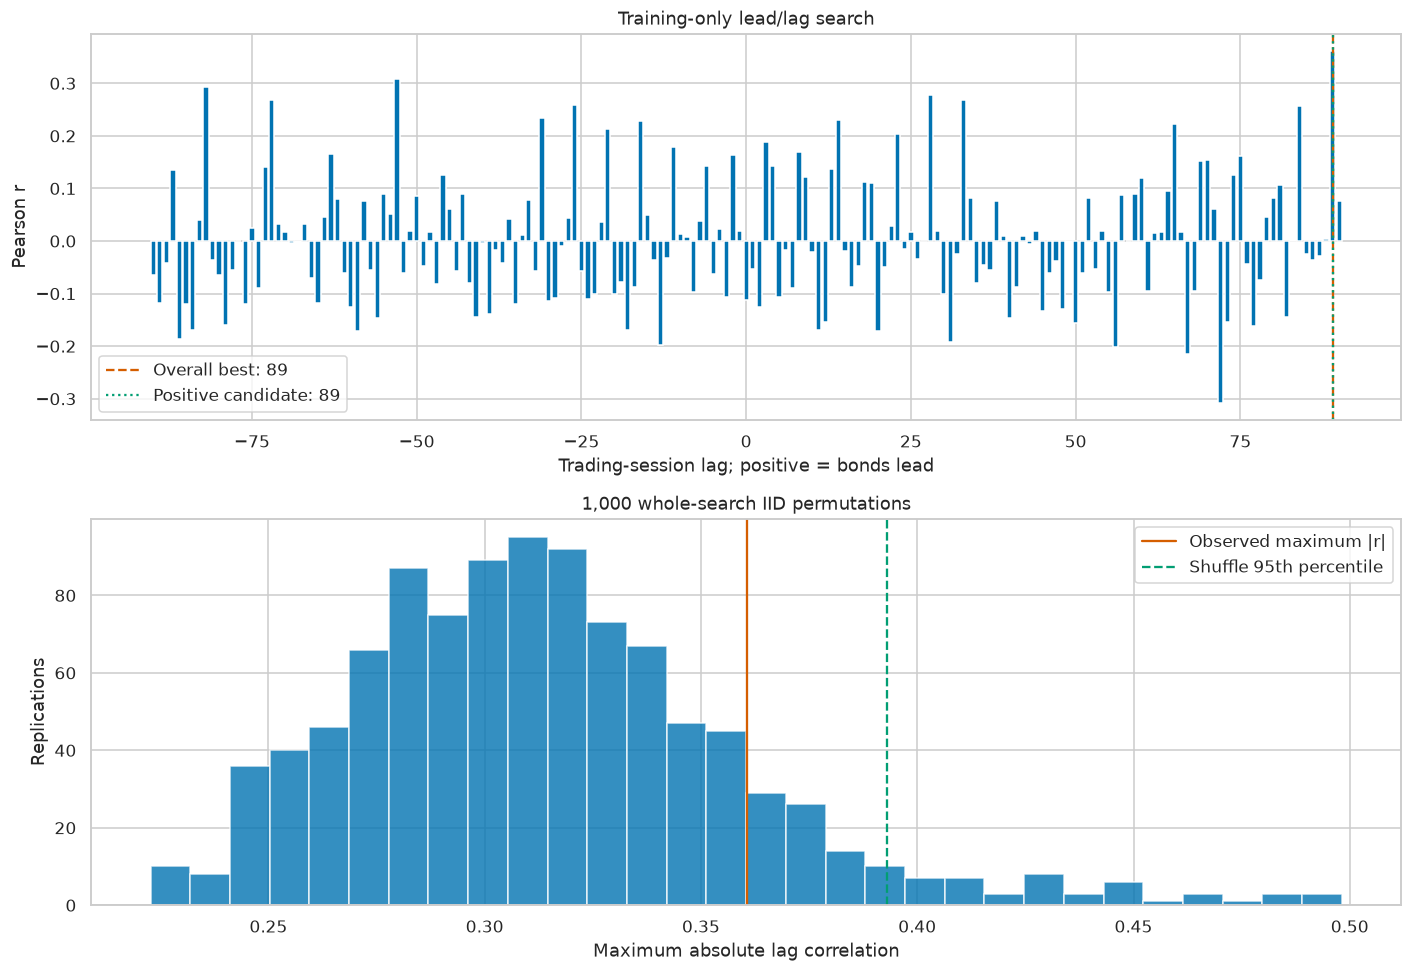

### Section 3 observations

Overall best lag: **89 sessions**, r = **0.3607**. Whole-search shuffle p = **0.1249**; it **does not pass** the 5% screen. The separate positive-only candidate is **89**. This training choice, not any test-set correlation, supplies the later forecast lag. A null result remains a null result even if a forecast can be mechanically evaluated.

In [4]:
lag_result = training_lags()
if lag_result is None:
    display(Markdown('**Section 3 blocked:** returns did not clear Section 2.'))
else:
    display(lag_result['table'])
    if lag_result['best_lag'] is None:
        display(Markdown('**Section 3 unavailable:** no estimable lag overlaps.'))
    else:
        fig, axes = plt.subplots(2, 1, figsize=(13, 9))
        axes[0].bar(lag_result['table']['lag'], lag_result['table']['correlation'], color=PALETTE[0])
        axes[0].axvline(lag_result['best_lag'], color=PALETTE[3], linestyle='--', label=f"Overall best: {lag_result['best_lag']}")
        if lag_result['forecast_lag'] is not None:
            axes[0].axvline(lag_result['forecast_lag'], color=PALETTE[2], linestyle=':', label=f"Positive candidate: {lag_result['forecast_lag']}")
        axes[0].set(title='Training-only lead/lag search', xlabel='Trading-session lag; positive = bonds lead', ylabel='Pearson r')
        axes[0].legend()
        axes[1].hist(lag_result['null_max'], bins=30, color=PALETTE[0], alpha=.8)
        axes[1].axvline(abs(lag_result['best_corr']), color=PALETTE[3], label='Observed maximum |r|')
        axes[1].axvline(lag_result['threshold'], color=PALETTE[2], linestyle='--', label='Shuffle 95th percentile')
        axes[1].set(title='1,000 whole-search IID permutations', xlabel='Maximum absolute lag correlation', ylabel='Replications')
        axes[1].legend()
        plt.tight_layout()
        plt.show()
        display(Markdown(f"### Section 3 observations\n\nOverall best lag: **{lag_result['best_lag']} sessions**, r = **{lag_result['best_corr']:.4f}**. "
            f"Whole-search shuffle p = **{lag_result['shuffle_pvalue']:.4f}**; it **{'passes' if lag_result['shuffle_pvalue'] < .05 else 'does not pass'}** the 5% screen. "
            f"The separate positive-only candidate is **{lag_result['forecast_lag']}**. This training choice, not any test-set correlation, supplies the later forecast lag. A null result remains a null result even if a forecast can be mechanically evaluated."))


### Section 3 interpretation checkpoint

A lag is evidence about temporal alignment, not a mechanism. Ask whether the winner is actually forward-looking, whether its overlap is small, and whether it exceeds the **whole-search** null. The nominal per-lag Pearson p-values are descriptive and unadjusted. A block/bootstrap dependence-aware null and an independent longer sample would be needed before treating a shuffle pass as robust.


## Section 4 — Multivariate Regression Against Known Indicators

Does a positive-lag bond signal add information beyond familiar indicators? Regress training S&P returns on the bond candidate, **previous-session VIX returns**, and a delayed monthly UMCSENT change. VIX is a familiar risk gauge, not automatically a leading predictor. Same-day VIX is excluded because it can react to the same equity move we are trying to forecast.

Monthly FRED values are indexed by observation period, not release day. We map changes to month-start plus two months and forward-fill on the **union** of release-proxy dates and trading dates, retaining weekend releases. Latest-vintage revisions still make this a **retrospective control exercise**, not a real-time macro backtest. Controls-only and augmented models use the same complete rows. OLS reports HAC(5)-robust p-values, coefficients and R²; rank-deficient or underdetermined designs are explicitly not estimable.

A bond coefficient that weakens after adding controls is consistent with redundancy, but does not prove it. A surviving coefficient is only potentially incremental: lag selection has already used these training outcomes, so even HAC p-values are post-selection/exploratory, not confirmatory novelty tests.


In [5]:
regression_result = training_regression()
if regression_result is None:
    display(Markdown('**Section 4 blocked:** no stationarity-supported positive-lag candidate.'))
else:
    display(regression_result['coefficients'])
    print(f"Status: {regression_result['status']}; complete observations: {regression_result['n_obs']}")
    print(f"Controls-only R²: {regression_result['baseline_rsquared']:.5f}; augmented R²: {regression_result['rsquared']:.5f}")
    p = regression_result['bond_pvalue']
    conclusion = ('not estimable' if not np.isfinite(p) else 'nominally significant after controls' if p < .05 else 'not significant after controls')
    display(Markdown(f'### Section 4 observations\n\nThe bond term is **{conclusion}** (HAC p = **{p:.4g}**). ' +
        'This cannot establish a novel mechanism or prove redundancy. The sample is training-only, the lag is selected, and UMCSENT is not point-in-time. Compare the same-row R² values without mistaking in-sample improvement for forecast performance.'))


,coefficient,pvalue,tstat
term,,,
const,0.00299,0.07160,1.80164
bond_lag,0.15034,0.00021,3.70364
vix_return,0.01148,0.23546,1.18642
umcsent_change,-0.07314,0.01947,-2.33650


Status: ok; complete observations: 60
Controls-only R²: 0.07784; augmented R²: 0.20652


### Section 4 observations

The bond term is **nominally significant after controls** (HAC p = **0.0002125**). This cannot establish a novel mechanism or prove redundancy. The sample is training-only, the lag is selected, and UMCSENT is not point-in-time. Compare the same-row R² values without mistaking in-sample improvement for forecast performance.

### Section 4 interpretation checkpoint

Risk appetite, disposable income, player participation, and in-game inflation are plausible hypotheses, not conclusions from a coefficient. A credible novelty claim needs vintage-correct controls and a controlled model that improves forecasts on new dates. Lack of significance can also reflect poor power, noisy prices, or sparse monthly changes.


## Section 5 — Granger Causality

Granger causality means additional linear predictive content beyond the outcome's own lagged history; it is **not true economic causation**. Test bond → S&P and the reverse direction at orders 1, 5, 10, 30, and the absolute best lag from Section 3 (omit zero and duplicates). An order $p$ includes **all** lags 1 through $p$, not just the single cross-correlation displacement.

Both directions use only the training sample. High orders can consume most of a short sample: infeasible fits are reported with reasons, never relabeled nonsignificant. Display F-statistics, raw p-values, and Holm-adjusted p-values across both directions and all estimable requested orders. The lag selected in Section 3 remains data-dependent, so this is an exploratory check even after multiplicity adjustment.


In [6]:
granger_results = training_granger()
if granger_results is None:
    display(Markdown('**Section 5 blocked:** stationarity or lag prerequisites unavailable.'))
else:
    display(granger_results)
    significant = granger_results.loc[granger_results['adjusted_pvalue'] < .05, ['direction', 'lag_order']]
    findings = significant.to_string(index=False) if not significant.empty else 'None at Holm-adjusted 5%.'
    display(Markdown('### Section 5 observations\n\nSignificant direction/order combinations:\n\n```text\n' + findings + '\n```\n\n'
        + 'Compare forward support with the sign of the Section 3 best lag. Reverse or bidirectional significance weakens a uniquely bond-led story and can reflect shared omitted drivers. A skipped large order says the sample cannot answer that question, not that the null was accepted.'))


,direction,lag_order,fstat,pvalue,adjusted_pvalue,status
0,bond_return -> sp500_return,1,0.40626,0.52488,1.00000,ok
1,bond_return -> sp500_return,5,1.89468,0.09937,0.79500,ok
2,bond_return -> sp500_return,10,0.94823,0.49228,1.00000,ok
3,bond_return -> sp500_return,30,1.03705,0.44126,1.00000,ok
4,bond_return -> sp500_return,89,NaN,NaN,NaN,skipped: n=149 must exceed 3*lag+1=268
5,sp500_return -> bond_return,1,0.07042,0.79110,1.00000,ok
6,sp500_return -> bond_return,5,0.63077,0.67657,1.00000,ok
7,sp500_return -> bond_return,10,0.86096,0.57163,1.00000,ok
8,sp500_return -> bond_return,30,1.02582,0.45476,1.00000,ok
9,sp500_return -> bond_return,89,NaN,NaN,NaN,skipped: n=149 must exceed 3*lag+1=268


### Section 5 observations

Significant direction/order combinations:

```text
None at Holm-adjusted 5%.
```

Compare forward support with the sign of the Section 3 best lag. Reverse or bidirectional significance weakens a uniquely bond-led story and can reflect shared omitted drivers. A skipped large order says the sample cannot answer that question, not that the null was accepted.

### Section 5 interpretation checkpoint

A forward-only result is stronger than contemporaneous correlation, but still vulnerable to omitted variables, timing errors and specification selection. If Granger and cross-correlation disagree, report the disagreement: do not change the tested orders to rescue the story.


## Section 6 — Rolling Correlation and Regime Stability

A weak average association can hide a regime-dependent relationship, but smooth rolling estimates also manufacture apparent regimes through heavily overlapping windows. Plot **60- and 90-trading-session** Pearson correlations of unshifted returns. They are descriptive contemporaneous associations, not the positive-lag forecasting rule.

**Method correction:** `ruptures` does not implement a formal econometric Bai–Perron significance test. Instead, this notebook uses dynamic-programming **multiple-break linear-regression segmentation**, allowing both intercept and bond-return slope in the S&P regression to change. Choose zero through the feasible maximum breaks by a BIC-style penalized residual criterion, with at least 60 observations per segment; inspect penalty multipliers 0.5, 1 and 2. Zero breaks is an actual candidate, unlike the old notebook's forced-break fit. Breaks are estimated on paired returns, not on an already-smoothed rolling correlation. Changes may reflect intercept, slope, or variance—not uniquely correlation.

This is related to multiple-break least-squares estimation, **not** a Bai–Perron sup-F test, p-value, or confidence interval. Short samples, residual autocorrelation and heteroskedasticity limit the criterion. A formal econometric significance claim requires a separate validated implementation with appropriate critical values.

**Holdout protection:** before Section 7, only training history is shown. After the frozen holdout report exists, this same cell shows the full date range. Section 7 also renders that full-range plot automatically. COVID March 2020 and the March 2022 rate-hike start are annotated only if inside the actual plotted range; otherwise they are explicitly listed as unavailable, never used to stretch the chart.


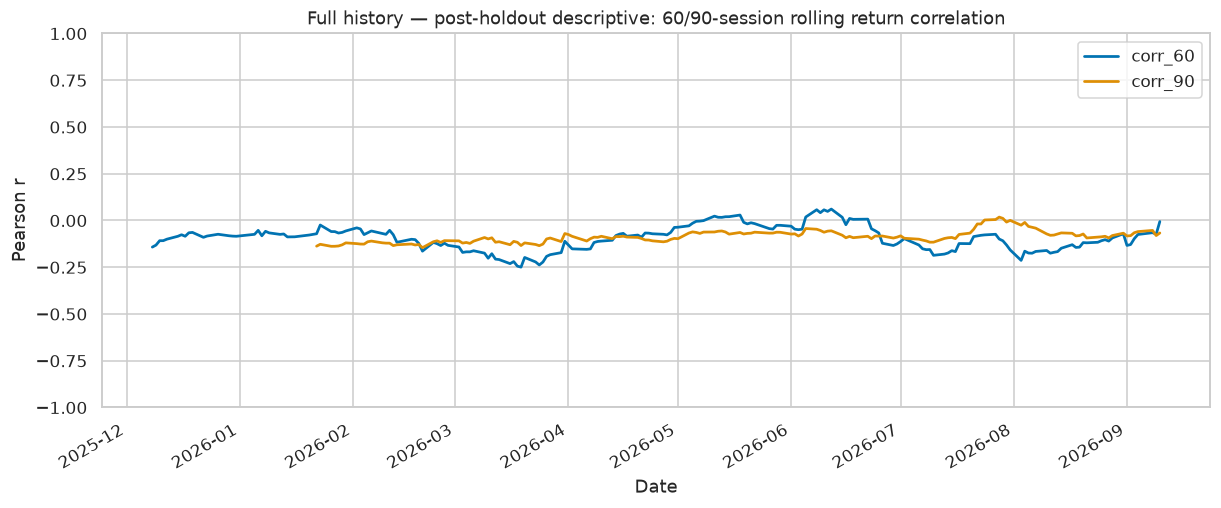

,penalty_multiplier,break_count
0,0.50000,0
1,1.00000,0
2,2.00000,0


,start,end,n_obs,correlation,status
0,2025-09-15,2026-09-10,249,-0.09189,ok


**Section 6 observations (Full history — post-holdout descriptive):** selected break dates: **none**. Status: ok. Events outside coverage: COVID crash, 2022 rate hikes. Their alignment cannot be tested. No selected breaks is not evidence of stability: short windows have low power. Penalty-sensitive dates are exploratory, not statistically certified breaks.

In [7]:
frozen_report = saved_holdout()
regime_result = render_regimes(analysis_df if frozen_report is not None else train_df,
    'Full history — post-holdout descriptive' if frozen_report is not None else 'Training only — holdout still sealed')
if frozen_report is None:
    display(Markdown('**Full-range regime analysis is deferred to Section 7.** Inspecting test correlations now would invalidate the planned holdout.'))


### Section 6 interpretation checkpoint

Report whether break dates persist across penalties and whether in-range macro markers actually coincide. No selected break is not proof of a stable relationship, especially with only a few 60-session segments. Unexpected dates motivate specific in-game hypotheses—membership-price changes, game updates, liquidity—not a retrofitted macro narrative.


## Section 7 — Out-of-Sample Validation

The first 60% supplied stationarity, lag selection and threshold values. The next 20% selects among the **predeclared** no-gate / median / 75th-percentile absolute-signal gates. The final 20% is not evaluated until that choice is frozen. The positive lag is fixed from training even when a reverse lag was the overall winner; no sign, lag or threshold is selected using test outcomes.

This is genuine expanding **walk-forward** evaluation in 20-session batches: at each batch boundary, refit a simple return-on-lagged-bond OLS using only strictly earlier observations. Predict up/down from its fitted return; gated-out or exactly zero predictions fall back to the majority direction of the same historical fitting rows. The baseline predicts that historical majority on the **identical scored dates**. Missing pairs and exactly flat target returns are excluded consistently; an up-majority tie resolves to up. Threshold magnitudes come from initial training, never later quantiles.

After validation, freeze the lag, gate, threshold and 20-session schedule. Test refits may consume earlier test outcomes **only after those dates have passed**; this is scheduled online learning, not hyperparameter retuning. Each test batch remains predicted before its own outcomes enter a fit. Validation accuracy is selected in-sample to validation and therefore optimistic; the final test is the one-shot check.

A per-dataset JSON ledger reserves the holdout before evaluation and stores the locked parameters and scored predictions atomically. Identical reruns load the report; changing the lag or forecasting implementation for the same fingerprint raises a spent-holdout error. Keep the ledger: deleting it or collecting a largely overlapping snapshot does not make old outcomes unseen. Once full-range regime plots have been viewed, later analyses of those dates are descriptive only.


lag         89.00000
quantile     0.00000
threshold    0.00000
window      20.00000
Name: Frozen rule, dtype: float64

,quantile,threshold,n,accuracy,baseline_accuracy,wilson_low,wilson_high
0,0.00000,0.00000,50,0.58000,0.56000,0.44233,0.70625
1,0.50000,0.01652,50,0.58000,0.56000,0.44233,0.70625
2,0.75000,0.02577,50,0.58000,0.56000,0.44233,0.70625


,partition,window_id,batch_start,batch_end,history_end,history_n,n,signal_correct,baseline_correct,accuracy,baseline_accuracy,wilson_low,wilson_high,baseline_wilson_low,baseline_wilson_high
0,validation,1,2026-04-20,2026-05-15,2026-04-17,60,20,9,11,0.45000,0.55000,0.25820,0.65791,0.34209,0.74180
1,validation,2,2026-05-18,2026-06-15,2026-05-15,80,20,14,14,0.70000,0.70000,0.48103,0.85452,0.48103,0.85452
2,validation,3,2026-06-16,2026-06-30,2026-06-15,100,10,6,3,0.60000,0.30000,0.31267,0.83182,0.10779,0.60322
3,test,1,2026-07-01,2026-07-29,2026-06-30,110,20,12,10,0.60000,0.50000,0.38658,0.78119,0.29930,0.70070
4,test,2,2026-07-30,2026-08-26,2026-07-29,130,20,9,10,0.45000,0.50000,0.25820,0.65791,0.29930,0.70070
5,test,3,2026-08-27,2026-09-10,2026-08-26,150,10,4,3,0.40000,0.30000,0.16818,0.68733,0.10779,0.60322


,split,n,signal_accuracy,majority_baseline,nominal_95%_Wilson
0,validation,50,0.58000,0.56000,"[0.4423344176857823, 0.7062499664528802]"
1,test,50,0.50000,0.46000,"[0.3664451431682858, 0.6335548568317142]"


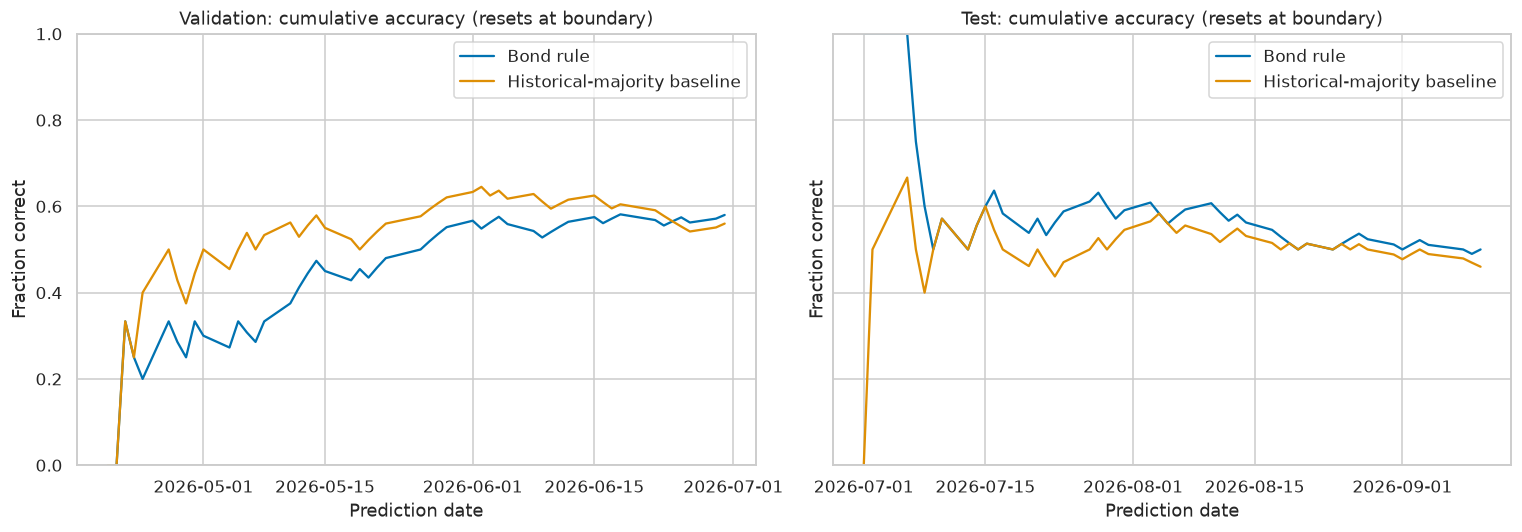

### Section 7 observations

Validation accuracy: **58.0%**; test: **50.0%**; matched test baseline: **46.0%**. Test-minus-validation change: **-8.0%**; test-minus-baseline: **+4.0%**. The rule beats this baseline descriptively; a fresh longer holdout and dependence-aware uncertainty are still required. Wilson intervals are nominal binomial intervals, not adjusted for dependent outcomes, model selection, or repeated researcher experimentation. Accuracy is not profitability or calibrated return prediction.

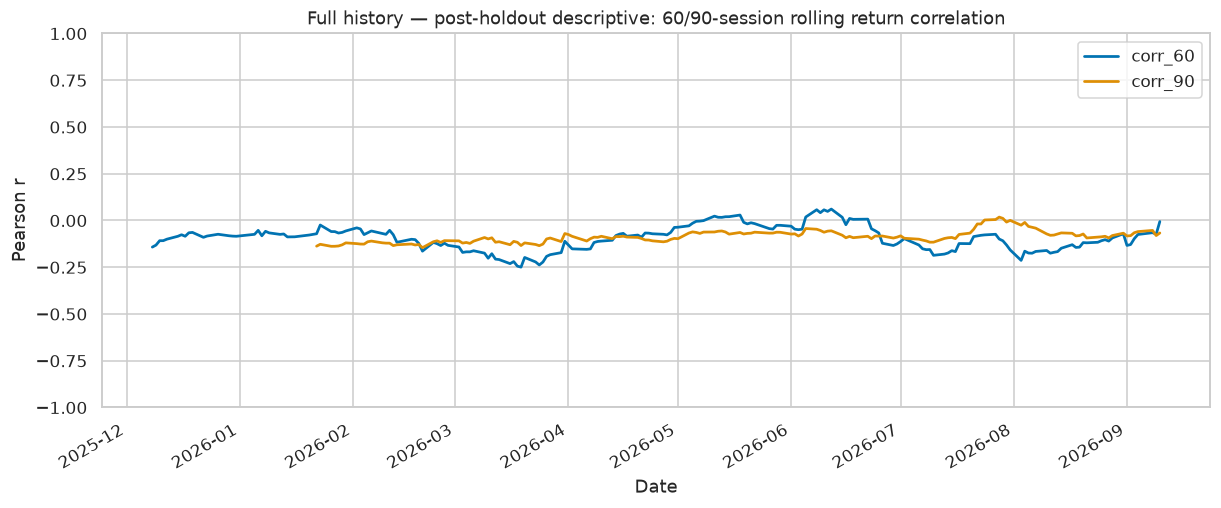

,penalty_multiplier,break_count
0,0.50000,0
1,1.00000,0
2,2.00000,0


,start,end,n_obs,correlation,status
0,2025-09-15,2026-09-10,249,-0.09189,ok


**Section 6 observations (Full history — post-holdout descriptive):** selected break dates: **none**. Status: ok. Events outside coverage: COVID crash, 2022 rate hikes. Their alignment cannot be tested. No selected breaks is not evidence of stability: short windows have low power. Penalty-sensitive dates are exploratory, not statistically certified breaks.

In [8]:
candidate = training_lags()
if candidate is None or candidate['forecast_lag'] is None:
    display(Markdown('**Section 7 blocked:** no stationarity-supported positive-lag candidate; no test outcomes evaluated.'))
else:
    holdout_result = run_holdout_once(context, candidate['forecast_lag'], cache_dir=CACHE_DIR)
    display(pd.Series(holdout_result['locked_parameters'], name='Frozen rule'))
    display(holdout_result['validation_candidates'])
    display(holdout_result['window_scores'])
    score_rows = []
    for split in ['validation', 'test']:
        score_rows.append({'split': split, 'n': holdout_result[f'{split}_n'],
            'signal_accuracy': holdout_result[f'{split}_accuracy'],
            'majority_baseline': holdout_result[f'{split}_baseline_accuracy'],
            'nominal_95%_Wilson': holdout_result[f'{split}_wilson_95']})
    display(pd.DataFrame(score_rows))
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    for ax, split in zip(axes, ['validation', 'test']):
        scored = holdout_result[f'{split}_scored']
        if not scored.empty:
            ax.plot(scored.index, scored['cumulative_signal_accuracy'], color=PALETTE[0], label='Bond rule')
            ax.plot(scored.index, scored['cumulative_baseline_accuracy'], color=PALETTE[1], label='Historical-majority baseline')
        ax.set(title=f'{split.title()}: cumulative accuracy (resets at boundary)', xlabel='Prediction date', ylabel='Fraction correct', ylim=(0, 1))
        ax.legend()
    plt.tight_layout()
    plt.show()
    va, ta = holdout_result['validation_accuracy'], holdout_result['test_accuracy']
    baseline = holdout_result['test_baseline_accuracy']
    if ta is None:
        display(Markdown('**Section 7 observations:** no eligible test outcomes; predictive performance is unavailable.'))
    else:
        display(Markdown(f'### Section 7 observations\n\nValidation accuracy: **{va:.1%}**; test: **{ta:.1%}**; matched test baseline: **{baseline:.1%}**. '
            f'Test-minus-validation change: **{ta-va:+.1%}**; test-minus-baseline: **{ta-baseline:+.1%}**. '
            + ('The rule beats this baseline descriptively; a fresh longer holdout and dependence-aware uncertainty are still required.' if ta > baseline else 'The rule does not beat the matched baseline; this does not support useful incremental directional prediction.')
            + ' Wilson intervals are nominal binomial intervals, not adjusted for dependent outcomes, model selection, or repeated researcher experimentation. Accuracy is not profitability or calibrated return prediction.'))
    # Only after the one-shot report is persisted may full history be inspected.
    full_regime_result = render_regimes(analysis_df, 'Full history — post-holdout descriptive')


### Section 7 interpretation checkpoint

Judge test performance against the **matched majority baseline**, not just 50%: equities can rise more often than they fall. A material validation-to-test drop suggests selection or instability. Even a small improvement on a tiny test sample is weak evidence. If performance fails, retain the null finding; if it survives, preregister the same rule on truly new dates rather than tweaking this test set.


## Section 8 — Summary and Open Questions

Collect the evidence, including failures and skipped tests. This section independently recomputes training prerequisites, but **never evaluates an unseen test set**. If Section 7 has not run, its summary says so and regime diagnostics remain training-only. A credible story needs forward timing, a whole-search signal, incremental controls, directional checks, and stable performance against a realistic baseline—not a tally of favorable nominal p-values.


In [9]:
st = training_stationarity()
lags = training_lags()
reg = training_regression()
gc = training_granger()
frozen = saved_holdout()
regimes = regime_analysis(analysis_df if frozen is not None else train_df)
if gc is None:
    granger_text = 'Blocked by stationarity/lag prerequisites'
else:
    sig = gc.loc[gc['adjusted_pvalue'] < .05, ['direction', 'lag_order']]
    granger_text = '; '.join(f'{r.direction}, order {r.lag_order}' for r in sig.itertuples()) or 'No Holm-adjusted significant orders'
    granger_text += f"; {gc['pvalue'].isna().sum()} requested fits not estimable"
if frozen is None:
    oos_text = 'Not evaluated; run Section 7 after reviewing the prespecified protocol'
elif frozen['test_accuracy'] is None:
    oos_text = 'No eligible test observations'
else:
    oos_text = f"Validation {frozen['validation_accuracy']:.1%}; test {frozen['test_accuracy']:.1%}; test baseline {frozen['test_baseline_accuracy']:.1%}; n={frozen['test_n']}"
summary_table = pd.DataFrame([
    {'section': 'Stationarity', 'key_result': 'Both returns pass ADF/KPSS' if returns_stationary(st) else 'Return checkpoint inconclusive/failed; dependent analyses blocked'},
    {'section': 'Best lag', 'key_result': 'Unavailable' if lags is None or lags['best_lag'] is None else f"Overall {lags['best_lag']}, r={lags['best_corr']:.4f}; forward candidate {lags['forecast_lag']} sessions"},
    {'section': 'Shuffle test', 'key_result': 'Unavailable' if lags is None else f"Whole-search IID p={lags['shuffle_pvalue']:.4f}"},
    {'section': 'Regression controls', 'key_result': 'Unavailable' if reg is None else f"Bond HAC p={reg['bond_pvalue']:.4g}; R²={reg['rsquared']:.4f}; {reg['status']}"},
    {'section': 'Granger', 'key_result': granger_text},
    {'section': 'Regime stability', 'key_result': f"{'Full history, post-holdout' if frozen is not None else 'Training only'}: {len(regimes['break_dates'])} BIC-selected breaks; exploratory, not Bai–Perron significance"},
    {'section': 'Out of sample', 'key_result': oos_text},
])
display(summary_table)
positive_evidence = (
    lags is not None and lags['best_lag'] is not None and lags['best_lag'] > 0
    and lags['shuffle_pvalue'] < .05 and reg is not None and reg['bond_pvalue'] < .05
    and gc is not None and ((gc['direction'] == 'bond_return -> sp500_return') & (gc['adjusted_pvalue'] < .05)).any()
    and frozen is not None and frozen['test_accuracy'] is not None
    and frozen['test_accuracy'] > frozen['test_baseline_accuracy']
)
display(Markdown('### Synthesis\n\n' + (
    'Several exploratory checks support a forward relationship, including a descriptive test-baseline advantage. This is a candidate for preregistered replication, **not established predictive novelty**.'
    if positive_evidence else
    'The evidence does not establish a genuinely novel forward bond signal. Null, inconclusive, or incomplete checks must not be replaced with the most flattering statistic.'
) + ' The most plausible explanations remain hypotheses: chance in a broad lag search, common risk/sentiment effects, or OSRS-specific inflation and player demand. These observations do not identify a causal mechanism. Limited API history, daily-average timing, revised macro data, and a short holdout bound every conclusion.'))


,section,key_result
0,Stationarity,Both returns pass ADF/KPSS
1,Best lag,"Overall 89, r=0.3607; forward candidate 89 ses..."
2,Shuffle test,Whole-search IID p=0.1249
3,Regression controls,Bond HAC p=0.0002125; R²=0.2065; ok
4,Granger,No Holm-adjusted significant orders; 2 request...
5,Regime stability,"Full history, post-holdout: 0 BIC-selected bre..."
6,Out of sample,Validation 58.0%; test 50.0%; test baseline 46...


### Synthesis

The evidence does not establish a genuinely novel forward bond signal. Null, inconclusive, or incomplete checks must not be replaced with the most flattering statistic. The most plausible explanations remain hypotheses: chance in a broad lag search, common risk/sentiment effects, or OSRS-specific inflation and player demand. These observations do not identify a causal mechanism. Limited API history, daily-average timing, revised macro data, and a short holdout bound every conclusion.

### Collective interpretation

The generated synthesis distinguishes a supported *candidate* from an established signal. Neither control significance nor Granger rejection can identify the mechanism. A reverse winner, a failed permutation screen, inconsistent directionality, or failure against the majority baseline all count against the original predictive claim. Regime-specific patterns need independent dates before receiving an economic story.

### Open questions and next steps

1. **Strengthen:** acquire a provenance-checked long-run bond archive from the instrument's actual launch, without silently splicing guide prices into transaction averages. Preserve the available rolling snapshots, their collection times, units, timezone conventions, and item identity. A 2013 OSRS bond history cannot exist.
2. **Falsify:** preregister the existing positive lag, preprocessing, refit schedule and baseline on genuinely new dates. Failure to improve on that baseline, equally strong shuffled/reverse signals, or collapse under sensible dependence-aware inference weakens the predictive claim. Do not reuse this spent holdout for tuning.
3. **Check multiplicity and dependence:** use block permutations or a stationary bootstrap, account for searching instruments as well as lags, and quantify matched forecast improvement rather than testing against 50% alone.
4. **Test novelty honestly:** obtain ALFRED/release-vintage sentiment and actual publication timestamps; compare lagged VIX, equity autoregression, rates, FX and other established predictors on the same future outcomes. The present delayed latest-vintage regression is not that test.
5. **Investigate mechanism:** collect bond volume/spreads, player activity, membership-price changes, in-game inflation baskets and update dates. Distinguish disposable-income demand from supply changes and gold inflation; compare other items as negative controls before claiming a macro channel.
6. **Validate regimes:** use longer samples and a formal heteroskedasticity/autocorrelation-robust Bai–Perron procedure with confidence intervals if significance of breaks is the question. The current `ruptures` segmentation is a sensitivity-tested descriptive estimate only.
7. **Economic usefulness:** direction is not a strategy. Evaluate magnitudes, calibrated probabilities, implementable timing, turnover and costs only after predictive replication. Do not infer profitability from these accuracy plots.

**Sources and methods:** [OSRS bond identity/launch](https://oldschool.runescape.wiki/w/Old_school_bond), [wiki price API](https://oldschool.runescape.wiki/w/RuneScape:Real-time_Prices), [FRED UMCSENT](https://fred.stlouisfed.org/series/UMCSENT), [arch unit-root tests](https://arch.readthedocs.io/en/latest/unitroot/tests.html), [statsmodels Granger tests](https://www.statsmodels.org/stable/generated/statsmodels.tsa.stattools.grangercausalitytests.html), [ruptures linear cost](https://centre-borelli.github.io/ruptures-docs/user-guide/costs/costlinear/).
